Mounted at /content/drive


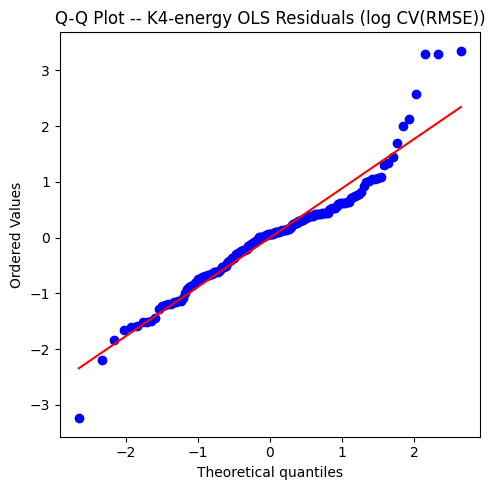

Levene (K4-energy, homogeneity across Unit x Range cells): stat=9.523, p=0.0000
Shapiro-Wilk on K4-energy residuals: W=0.940, p=0.0000


In [1]:
# S6A  K4-energy residual diagnostics (Q-Q, Levene, Shapiro on residuals)
from google.colab import drive
drive.mount('/content/drive')

import os, json, sys, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

BASE    = '/content/drive/MyDrive/BEM-LLM'
DATA    = f'{BASE}/data'
ANALIZ  = f'{BASE}/analiz'
S5_DIR  = f'{ANALIZ}/sprint5_metrics'
S6_DIR  = f'{ANALIZ}/sprint6_robustness'
FIG_DIR = f'{S6_DIR}/figures'
os.makedirs(S6_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

with open(f'{ANALIZ}/protocol.json') as f:
    protocol = json.load(f)
MAIN_CLIMATE = protocol['climates']['main']

cvrmse_all = pd.read_csv(f'{S5_DIR}/K2_cvrmse_nmbe.csv')
model_df = cvrmse_all[(cvrmse_all.source_type == 'llm') & (cvrmse_all.climate == MAIN_CLIMATE)].copy()
model_df['Unit'] = model_df['format'].isin(['F2', 'F4']).astype(int)
model_df['Range'] = model_df['format'].isin(['F3', 'F4']).astype(int)
model_df['log_cvrmse'] = np.log1p(model_df['cvrmse_pct'])

ols_model = smf.ols('log_cvrmse ~ C(Unit)*C(Range) + C(building) + C(model)', data=model_df).fit()
resid = ols_model.resid

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(resid, dist='norm', plot=ax)
plt.title('Q-Q Plot -- K4-energy OLS Residuals (log CV(RMSE))')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/S6A_qqplot.png', dpi=200)
plt.show()

cells = model_df.groupby(['Unit', 'Range'])['log_cvrmse'].apply(list)
levene_stat, levene_p = stats.levene(*cells.values)
sw_resid = stats.shapiro(resid)

print(f'Levene (K4-energy, homogeneity across Unit x Range cells): stat={levene_stat:.3f}, p={levene_p:.4f}')
print(f'Shapiro-Wilk on K4-energy residuals: W={sw_resid.statistic:.3f}, p={sw_resid.pvalue:.4f}')

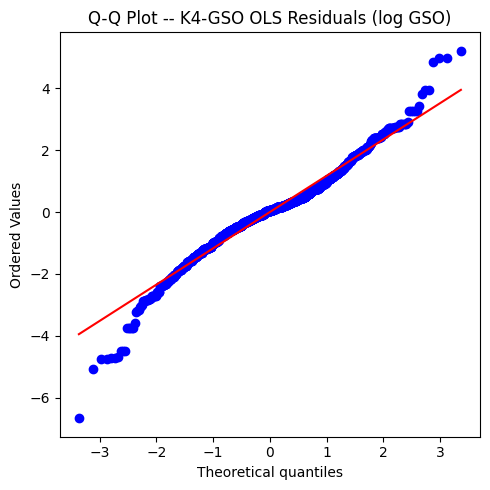

Levene (K4-GSO, homogeneity across Unit x Range cells): stat=10.198, p=0.0000
Shapiro-Wilk on K4-GSO residuals: W=0.969, p=0.0000


In [2]:
# S6A2  K4-GSO residual diagnostics -- parallel to S6A, for the
# parameter-level formula log(1+GSO) ~ Unit*Range + Building + Parameter,
# which S6A does not cover (Sprint 5's S5E2).
gso_df = pd.read_csv(f'{S5_DIR}/K1_gso.csv')
gso_model_df = gso_df.copy()
gso_model_df['Unit'] = gso_model_df['format'].isin(['F2', 'F4']).astype(int)
gso_model_df['Range'] = gso_model_df['format'].isin(['F3', 'F4']).astype(int)
gso_model_df['log_gso'] = np.log1p(gso_model_df['gso_pct'])

ols_gso = smf.ols('log_gso ~ C(Unit)*C(Range) + C(building) + C(true_name)', data=gso_model_df).fit()
resid_gso = ols_gso.resid

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(resid_gso, dist='norm', plot=ax)
plt.title('Q-Q Plot -- K4-GSO OLS Residuals (log GSO)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/S6A2_qqplot.png', dpi=200)
plt.show()

cells_gso = gso_model_df.groupby(['Unit', 'Range'])['log_gso'].apply(list)
levene_stat_gso, levene_p_gso = stats.levene(*cells_gso.values)
sw_resid_gso = stats.shapiro(resid_gso)

print(f'Levene (K4-GSO, homogeneity across Unit x Range cells): stat={levene_stat_gso:.3f}, p={levene_p_gso:.4f}')
print(f'Shapiro-Wilk on K4-GSO residuals: W={sw_resid_gso.statistic:.3f}, p={sw_resid_gso.pvalue:.4f}')

In [3]:
# S6B  K4-energy nonparametric sensitivity: Kruskal-Wallis + permutation
# test on the MARGINAL (unadjusted) Unit/Range effect. Reported alongside,
# not as a replacement for, the ANOVA's building/model-adjusted partial
# F-test.
kw_unit = stats.kruskal(*[g['log_cvrmse'].values for _, g in model_df.groupby('Unit')])
kw_range = stats.kruskal(*[g['log_cvrmse'].values for _, g in model_df.groupby('Range')])
print(f'Kruskal-Wallis (energy), Unit: H={kw_unit.statistic:.3f}, p={kw_unit.pvalue:.4f}')
print(f'Kruskal-Wallis (energy), Range: H={kw_range.statistic:.3f}, p={kw_range.pvalue:.4f}')


def permutation_test_main_effect(df, factor, value_col, n_perm=5000, seed=0):
    """Single permutation per draw: the same shuffled label vector supplies
    both the group-1 and group-0 side, so every point lands in exactly one
    group per draw -- as a valid permutation null requires. (Reused for
    both the energy-level and GSO-level checks via value_col.)"""
    rng = np.random.default_rng(seed)
    groups = df[factor].values
    y = df[value_col].values
    observed = abs(y[groups == 1].mean() - y[groups == 0].mean())
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(groups)
        diff = abs(y[perm == 1].mean() - y[perm == 0].mean())
        if diff >= observed:
            count += 1
    return observed, count / n_perm


obs_unit, p_unit = permutation_test_main_effect(model_df, 'Unit', 'log_cvrmse')
obs_range, p_range = permutation_test_main_effect(model_df, 'Range', 'log_cvrmse')
print(f'Permutation (marginal, energy), Unit: diff={obs_unit:.4f}, p={p_unit:.4f}')
print(f'Permutation (marginal, energy), Range: diff={obs_range:.4f}, p={p_range:.4f}')

robustness_summary = pd.DataFrame([
    {'test': 'Kruskal-Wallis Unit (energy, marginal)', 'statistic': kw_unit.statistic, 'p': kw_unit.pvalue},
    {'test': 'Kruskal-Wallis Range (energy, marginal)', 'statistic': kw_range.statistic, 'p': kw_range.pvalue},
    {'test': 'Permutation Unit (energy, marginal)', 'statistic': obs_unit, 'p': p_unit},
    {'test': 'Permutation Range (energy, marginal)', 'statistic': obs_range, 'p': p_range},
])
robustness_summary.to_csv(f'{S6_DIR}/S6B_nonparametric_robustness.csv', index=False)

Kruskal-Wallis (energy), Unit: H=11.423, p=0.0007
Kruskal-Wallis (energy), Range: H=7.744, p=0.0054
Permutation (marginal, energy), Unit: diff=0.7326, p=0.0002
Permutation (marginal, energy), Range: diff=0.8932, p=0.0000


In [4]:
# S6B2  K4-GSO nonparametric sensitivity -- parallel to S6B, using the
# same (corrected) permutation_test_main_effect function.
kw_unit_gso = stats.kruskal(*[g['log_gso'].values for _, g in gso_model_df.groupby('Unit')])
kw_range_gso = stats.kruskal(*[g['log_gso'].values for _, g in gso_model_df.groupby('Range')])
print(f'Kruskal-Wallis (GSO), Unit: H={kw_unit_gso.statistic:.3f}, p={kw_unit_gso.pvalue:.4f}')
print(f'Kruskal-Wallis (GSO), Range: H={kw_range_gso.statistic:.3f}, p={kw_range_gso.pvalue:.4f}')

obs_unit_gso, p_unit_gso = permutation_test_main_effect(gso_model_df, 'Unit', 'log_gso')
obs_range_gso, p_range_gso = permutation_test_main_effect(gso_model_df, 'Range', 'log_gso')
print(f'Permutation (marginal, GSO), Unit: diff={obs_unit_gso:.4f}, p={p_unit_gso:.4f}')
print(f'Permutation (marginal, GSO), Range: diff={obs_range_gso:.4f}, p={p_range_gso:.4f}')

robustness_summary_gso = pd.DataFrame([
    {'test': 'Kruskal-Wallis Unit (GSO, marginal)', 'statistic': kw_unit_gso.statistic, 'p': kw_unit_gso.pvalue},
    {'test': 'Kruskal-Wallis Range (GSO, marginal)', 'statistic': kw_range_gso.statistic, 'p': kw_range_gso.pvalue},
    {'test': 'Permutation Unit (GSO, marginal)', 'statistic': obs_unit_gso, 'p': p_unit_gso},
    {'test': 'Permutation Range (GSO, marginal)', 'statistic': obs_range_gso, 'p': p_range_gso},
])
robustness_summary_gso.to_csv(f'{S6_DIR}/S6B2_nonparametric_robustness_gso.csv', index=False)

Kruskal-Wallis (GSO), Unit: H=54.096, p=0.0000
Kruskal-Wallis (GSO), Range: H=92.393, p=0.0000
Permutation (marginal, GSO), Unit: diff=0.6469, p=0.0000
Permutation (marginal, GSO), Range: diff=0.7826, p=0.0000


                     raw     log
C(Unit)           0.0470  0.0971
C(Range)          0.0466  0.1315
C(building)       0.0333  0.2285
C(model)          0.0001  0.0003
C(Unit):C(Range)  0.0731  0.0781


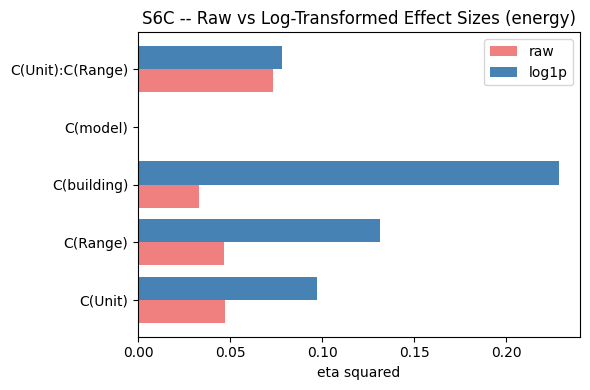

In [5]:
# S6C  Raw vs log-transformed effect size comparison (K4-energy)
ols_raw = smf.ols('cvrmse_pct ~ C(Unit)*C(Range) + C(building) + C(model)', data=model_df).fit()
anova_raw = anova_lm(ols_raw, typ=2)
anova_raw['eta_sq'] = anova_raw['sum_sq'] / anova_raw['sum_sq'].sum()

anova_log = anova_lm(ols_model, typ=2)
anova_log['eta_sq'] = anova_log['sum_sq'] / anova_log['sum_sq'].sum()

eta_compare = pd.DataFrame({'raw': anova_raw['eta_sq'], 'log': anova_log['eta_sq']}).drop('Residual', errors='ignore')
eta_compare.to_csv(f'{S6_DIR}/S6C_eta_squared_comparison.csv')
print(eta_compare.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(eta_compare))
ax.barh(x - 0.2, eta_compare['raw'], height=0.4, label='raw', color='lightcoral')
ax.barh(x + 0.2, eta_compare['log'], height=0.4, label='log1p', color='steelblue')
ax.set_yticks(x); ax.set_yticklabels(eta_compare.index)
ax.set_xlabel('eta squared'); ax.legend()
plt.title('S6C -- Raw vs Log-Transformed Effect Sizes (energy)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/S6C_eta_comparison.png', dpi=200)
plt.show()

                     raw     log
C(Unit)           0.0053  0.0347
C(Range)          0.0054  0.0508
C(building)       0.0028  0.0016
C(true_name)      0.0423  0.4112
C(Unit):C(Range)  0.0052  0.0310


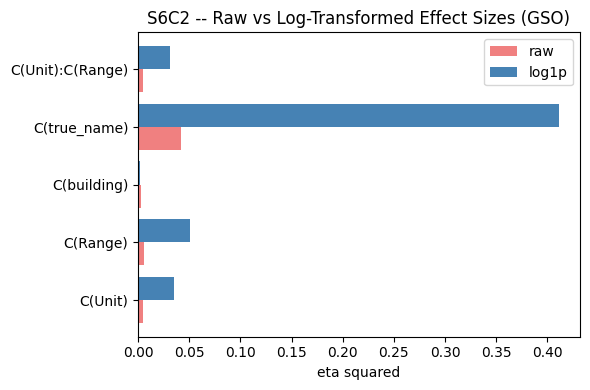

In [6]:
# S6C2  Raw vs log-transformed effect size comparison (K4-GSO) -- parallel to S6C.
ols_gso_raw = smf.ols('gso_pct ~ C(Unit)*C(Range) + C(building) + C(true_name)', data=gso_model_df).fit()
anova_gso_raw = anova_lm(ols_gso_raw, typ=2)
anova_gso_raw['eta_sq'] = anova_gso_raw['sum_sq'] / anova_gso_raw['sum_sq'].sum()

anova_gso_log = anova_lm(ols_gso, typ=2)
anova_gso_log['eta_sq'] = anova_gso_log['sum_sq'] / anova_gso_log['sum_sq'].sum()

eta_compare_gso = pd.DataFrame({'raw': anova_gso_raw['eta_sq'], 'log': anova_gso_log['eta_sq']}).drop('Residual', errors='ignore')
eta_compare_gso.to_csv(f'{S6_DIR}/S6C2_eta_squared_comparison_gso.csv')
print(eta_compare_gso.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(eta_compare_gso))
ax.barh(x - 0.2, eta_compare_gso['raw'], height=0.4, label='raw', color='lightcoral')
ax.barh(x + 0.2, eta_compare_gso['log'], height=0.4, label='log1p', color='steelblue')
ax.set_yticks(x); ax.set_yticklabels(eta_compare_gso.index)
ax.set_xlabel('eta squared'); ax.legend()
plt.title('S6C2 -- Raw vs Log-Transformed Effect Sizes (GSO)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/S6C2_eta_comparison_gso.png', dpi=200)
plt.show()

In [7]:
# S6D  K4-energy per-model robustness: does the Unit/Range effect hold
# within each LLM separately, or is a pooled result driven by only one model?
per_model_rows = []
for model_name, g in model_df.groupby('model'):
    m = smf.ols('log_cvrmse ~ C(Unit)*C(Range) + C(building)', data=g).fit()
    a = anova_lm(m, typ=2)
    a['eta_sq'] = a['sum_sq'] / a['sum_sq'].sum()
    for term in ['C(Unit)', 'C(Range)', 'C(Unit):C(Range)']:
        if term in a.index:
            per_model_rows.append({'model': model_name, 'term': term,
                                    'F': a.loc[term, 'F'], 'p': a.loc[term, 'PR(>F)'],
                                    'eta_sq': a.loc[term, 'eta_sq']})

per_model_df = pd.DataFrame(per_model_rows)
per_model_df.to_csv(f'{S6_DIR}/S6D_per_model_anova.csv', index=False)
print(per_model_df.round(4).to_string(index=False))

                  model             term       F      p  eta_sq
llama-3.3-70b-versatile          C(Unit)  4.1459 0.0458  0.0151
llama-3.3-70b-versatile         C(Range)  6.6300 0.0123  0.0242
llama-3.3-70b-versatile C(Unit):C(Range)  1.7874 0.1858  0.0065
    openai/gpt-oss-120b          C(Unit) 22.5079 0.0000  0.1274
    openai/gpt-oss-120b         C(Range) 32.8092 0.0000  0.1858
    openai/gpt-oss-120b C(Unit):C(Range) 11.9990 0.0008  0.0679


In [8]:
# S6D2  K4-GSO per-model robustness -- parallel to S6D.
per_model_gso_rows = []
for model_name, g in gso_model_df.groupby('model'):
    m = smf.ols('log_gso ~ C(Unit)*C(Range) + C(building) + C(true_name)', data=g).fit()
    a = anova_lm(m, typ=2)
    a['eta_sq'] = a['sum_sq'] / a['sum_sq'].sum()
    for term in ['C(Unit)', 'C(Range)', 'C(Unit):C(Range)']:
        if term in a.index:
            per_model_gso_rows.append({'model': model_name, 'term': term,
                                        'F': a.loc[term, 'F'], 'p': a.loc[term, 'PR(>F)'],
                                        'eta_sq': a.loc[term, 'eta_sq']})

per_model_gso_df = pd.DataFrame(per_model_gso_rows)
per_model_gso_df.to_csv(f'{S6_DIR}/S6D2_per_model_anova_gso.csv', index=False)
print(per_model_gso_df.round(4).to_string(index=False))

                  model             term        F      p  eta_sq
llama-3.3-70b-versatile          C(Unit) 244.0018 0.0000  0.1045
llama-3.3-70b-versatile         C(Range) 332.2894 0.0000  0.1423
llama-3.3-70b-versatile C(Unit):C(Range) 228.0819 0.0000  0.0976
    openai/gpt-oss-120b          C(Unit)   7.1347 0.0077  0.0030
    openai/gpt-oss-120b         C(Range)  15.1516 0.0001  0.0063
    openai/gpt-oss-120b C(Unit):C(Range)   4.8153 0.0285  0.0020


In [9]:
# S6E  Seed-count sensitivity: 5 seeds vs first 3, for GSO medians, and
# for both K4 models' eta-sq (energy and GSO).
seeds_sorted = sorted(gso_df['seed'].unique())
seeds_3 = seeds_sorted[:3]

gso_3seed = gso_df[gso_df.seed.isin(seeds_3)]
seed_sensitivity = pd.DataFrame({
    '5_seed_median': gso_df.groupby('format')['gso_pct'].median(),
    '3_seed_median': gso_3seed.groupby('format')['gso_pct'].median(),
})
seed_sensitivity['abs_diff'] = (seed_sensitivity['5_seed_median'] - seed_sensitivity['3_seed_median']).abs()
seed_sensitivity.to_csv(f'{S6_DIR}/S6E_seed_sensitivity.csv')
print(seed_sensitivity.round(2).to_string())

# -- energy-level (K4) eta-sq sensitivity --
model_df_3seed = model_df[model_df.seed.isin(seeds_3)]
cell_sizes_3seed = model_df_3seed.groupby(['Unit', 'Range', 'building', 'model']).size()
if cell_sizes_3seed.min() >= 1:
    ols_3seed = smf.ols('log_cvrmse ~ C(Unit)*C(Range) + C(building) + C(model)', data=model_df_3seed).fit()
    anova_3seed = anova_lm(ols_3seed, typ=2)
    anova_3seed['eta_sq'] = anova_3seed['sum_sq'] / anova_3seed['sum_sq'].sum()
    eta_seed_compare = pd.DataFrame({'5_seed': anova_log['eta_sq'], '3_seed': anova_3seed['eta_sq']}).drop('Residual', errors='ignore')
    eta_seed_compare.to_csv(f'{S6_DIR}/S6E_eta_seed_sensitivity.csv')
    print('\neta squared (energy), 5 seeds vs 3 seeds:')
    print(eta_seed_compare.round(4).to_string())
else:
    print(f'Skipped (energy): at least one (Unit, Range, building, model) cell is empty in the '
          f'3-seed subset (min cell size = {cell_sizes_3seed.min()}).')

# -- GSO-level (K4-GSO) eta-sq sensitivity --
gso_model_df_3seed = gso_model_df[gso_model_df.seed.isin(seeds_3)]
cell_sizes_3seed_gso = gso_model_df_3seed.groupby(['Unit', 'Range', 'building', 'true_name']).size()
if cell_sizes_3seed_gso.min() >= 1:
    ols_gso_3seed = smf.ols('log_gso ~ C(Unit)*C(Range) + C(building) + C(true_name)', data=gso_model_df_3seed).fit()
    anova_gso_3seed = anova_lm(ols_gso_3seed, typ=2)
    anova_gso_3seed['eta_sq'] = anova_gso_3seed['sum_sq'] / anova_gso_3seed['sum_sq'].sum()
    anova_gso_full = anova_lm(ols_gso, typ=2)
    anova_gso_full['eta_sq'] = anova_gso_full['sum_sq'] / anova_gso_full['sum_sq'].sum()
    eta_seed_compare_gso = pd.DataFrame({'5_seed': anova_gso_full['eta_sq'], '3_seed': anova_gso_3seed['eta_sq']}).drop('Residual', errors='ignore')
    eta_seed_compare_gso.to_csv(f'{S6_DIR}/S6E_eta_seed_sensitivity_gso.csv')
    print('\neta squared (GSO), 5 seeds vs 3 seeds:')
    print(eta_seed_compare_gso.round(4).to_string())
else:
    print(f'Skipped (GSO): at least one (Unit, Range, building, parameter) cell is empty in the '
          f'3-seed subset (min cell size = {cell_sizes_3seed_gso.min()}).')

        5_seed_median  3_seed_median  abs_diff
format                                        
F1              83.58          83.18      0.40
F2              20.78          20.62      0.16
F3              15.26          15.26      0.00
F4              15.16          15.26      0.10

eta squared (energy), 5 seeds vs 3 seeds:
                  5_seed  3_seed
C(Unit)           0.0971  0.1184
C(Range)          0.1315  0.1239
C(building)       0.2285  0.2306
C(model)          0.0003  0.0000
C(Unit):C(Range)  0.0781  0.0896

eta squared (GSO), 5 seeds vs 3 seeds:
                  5_seed  3_seed
C(Unit)           0.0347  0.0349
C(Range)          0.0508  0.0488
C(building)       0.0016  0.0018
C(true_name)      0.4112  0.4301
C(Unit):C(Range)  0.0310  0.0332


In [10]:
# S6F  Generalizability note: full 16-building LOBO pool coverage recap.
with open(f'{ANALIZ}/sprint2_lobo/lobo_diagnostics.json') as f:
    lobo_diag = json.load(f)

try:
    coverage_df = pd.DataFrame(lobo_diag['containment_by_building'])
    assert {'contained', 'total'}.issubset(coverage_df.columns)
    print(f'Full pool (n=16) LOO coverage: {coverage_df.contained.sum()}/{coverage_df.total.sum()} '
          f'({coverage_df.contained.sum()/coverage_df.total.sum()*100:.1f}%)')
    coverage_df.to_csv(f'{S6_DIR}/S6F_generalizability_note.csv', index=False)
except (KeyError, AssertionError) as e:
    print(f'lobo_diagnostics.json structure did not match expectations ({e}); inspect manually.')
    coverage_df = pd.DataFrame()

print('Coverage is a property of the 16-building ASHRAE prototype family used; a smaller '
      'reference pool would widen LOBO ranges and likely raise coverage while reducing '
      'informativeness -- reported as a scope limitation, not re-derived from a smaller pool.')

Full pool (n=16) LOO coverage: 42/45 (93.3%)
Coverage is a property of the 16-building ASHRAE prototype family used; a smaller reference pool would widen LOBO ranges and likely raise coverage while reducing informativeness -- reported as a scope limitation, not re-derived from a smaller pool.


In [11]:
# S6G  Reproducibility Audit
def sha256_file(path):
    if not os.path.exists(path):
        return None
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()[:16]


def extract_schema_keys(system_prompt):
    try:
        start = system_prompt.index('{')
        end = system_prompt.rindex('}') + 1
        return tuple(sorted(json.loads(system_prompt[start:end]).keys()))
    except (ValueError, json.JSONDecodeError):
        return None


audit = {
    'lobo_range_table_hash': sha256_file(f'{ANALIZ}/sprint2_lobo/lobo_range_table.json'),
    'parameter_object_mapping_hash': sha256_file(f'{ANALIZ}/sprint2_lobo/parameter_object_mapping.csv'),
    'protocol_hash': sha256_file(f'{ANALIZ}/protocol.json'),
}

for sprint_env in ['environment_sprint1.json', 'environment_sprint2.json', 'environment_sprint3.json',
                    'environment_sprint4_main.json', 'environment_sprint4_stress.json',
                    'environment_sprint5.json', 'environment_sprint5b.json']:
    path = f'{DATA}/{sprint_env}'
    audit[sprint_env] = json.load(open(path)) if os.path.exists(path) else 'MISSING'

f1 = json.load(open(f'{ANALIZ}/sprint3_prompts/f1_prompts.json'))
f4 = json.load(open(f'{ANALIZ}/sprint3_prompts/f4_prompts.json'))

f1_schema_keys = [extract_schema_keys(p['system_prompt']) for p in f1]
f1_schemas = set(k for k in f1_schema_keys if k is not None)
audit['schema_identical_across_buildings'] = len(f1_schemas) == 1
audit['schema_extraction_failures'] = sum(1 for k in f1_schema_keys if k is None)
audit['f1_prompt_count'] = len(f1)
audit['f4_prompt_count'] = len(f4)

with open(f'{S6_DIR}/S6G_reproducibility_audit.json', 'w') as f:
    json.dump(audit, f, indent=2, default=str)

print('=== Reproducibility Audit ===')
for k, v in audit.items():
    print(f'{"MISSING" if v == "MISSING" else "OK":8s} {k}')
if audit['schema_extraction_failures'] > 0:
    print(f'WARNING: {audit["schema_extraction_failures"]} F1 prompt(s) failed schema extraction -- '
          f'schema_identical result excludes these.')

=== Reproducibility Audit ===
OK       lobo_range_table_hash
OK       parameter_object_mapping_hash
OK       protocol_hash
OK       environment_sprint1.json
OK       environment_sprint2.json
OK       environment_sprint3.json
OK       environment_sprint4_main.json
OK       environment_sprint4_stress.json
OK       environment_sprint5.json
OK       environment_sprint5b.json
OK       schema_identical_across_buildings
OK       schema_extraction_failures
OK       f1_prompt_count
OK       f4_prompt_count


In [12]:
# S6H  Final robustness summary and environment record -- now covers both
# the K4-energy and K4-GSO formulas.
summary = {
    'sprint': 'Sprint 6',
    'design_note': 'Mixed-effects LRT / marginal-conditional R2 (original plan) dropped: '
                   'main-climate data has exactly one observation per (building, format, '
                   'model, seed) group [energy] or per (building, format, model, seed, '
                   'parameter) group [GSO], so a random-intercept model is degenerate in '
                   'both cases. Replaced with residual diagnostics, nonparametric '
                   'sensitivity checks, and per-model robustness (S6A-E), run in parallel '
                   'for both K4 formulas.',
    'energy_shapiro_resid_p': float(sw_resid.pvalue),
    'energy_levene_p': float(levene_p),
    'energy_kruskal_unit_p': float(kw_unit.pvalue),
    'energy_kruskal_range_p': float(kw_range.pvalue),
    'gso_shapiro_resid_p': float(sw_resid_gso.pvalue),
    'gso_levene_p': float(levene_p_gso),
    'gso_kruskal_unit_p': float(kw_unit_gso.pvalue),
    'gso_kruskal_range_p': float(kw_range_gso.pvalue),
    'schema_identical_across_buildings': audit['schema_identical_across_buildings'],
}
with open(f'{DATA}/environment_sprint6.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "sprint": "Sprint 6",
  "design_note": "Mixed-effects LRT / marginal-conditional R2 (original plan) dropped: main-climate data has exactly one observation per (building, format, model, seed) group [energy] or per (building, format, model, seed, parameter) group [GSO], so a random-intercept model is degenerate in both cases. Replaced with residual diagnostics, nonparametric sensitivity checks, and per-model robustness (S6A-E), run in parallel for both K4 formulas.",
  "energy_shapiro_resid_p": 1.1541999640672826e-06,
  "energy_levene_p": 7.588759552430741e-06,
  "energy_kruskal_unit_p": 0.0007254862699220115,
  "energy_kruskal_range_p": 0.005388314323225726,
  "gso_shapiro_resid_p": 3.8135022741852496e-19,
  "gso_levene_p": 1.1684426164080913e-06,
  "gso_kruskal_unit_p": 1.909016727451924e-13,
  "gso_kruskal_range_p": 7.105517914430462e-22,
  "schema_identical_across_buildings": true
}


# Sprint 6 — Robustness Checks and Reproducibility

Stress-tests the reliability of Sprint 5's two K4 models (energy-level and
parameter-level Unit×Range ANOVA) with four independent, complementary
checks, run in parallel for both formulas.

**Checks:** (i) residual diagnostics — Q-Q, Levene, Shapiro-Wilk; (ii)
non-parametric sensitivity — marginal Kruskal-Wallis and a single-permutation
test on Unit/Range; (iii) per-model robustness — Unit/Range/interaction
re-fit separately for Llama-3.3-70B and gpt-oss-120b; (iv) seed-count
sensitivity — 5 vs. first-3 seeds. Raw-vs-log effect-size comparison (S6C/C2)
and full-pool LOBO generalizability (S6F) are reported alongside.

**S6G/H:** an automated Reproducibility Audit collects every sprint's
environment record and source-file SHA-256 hashes into one file, and a
final environment record consolidates all robustness p-values used in the
manuscript.

**Dependency:** requires `environment_sprint5.json` and
`environment_sprint5b.json` from Sprint 5 to be present before running S6G.